In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
features = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/elliptic/elliptic_txs_features.csv', header=None)
classes = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/elliptic/elliptic_txs_classes.csv')
edges = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/elliptic/elliptic_txs_edgelist.csv')

print('Features shape:', features.shape)
print('Classes shape:', classes.shape)
print('Edges shape:', edges.shape)
print(classes['class'].value_counts())

Features shape: (203769, 167)
Classes shape: (203769, 2)
Edges shape: (234355, 2)
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64


In [8]:
features.columns = ['txId'] + [f'feat_{i}' for i in range(1, 167)]
df = features.merge(classes, on='txId')
df = df[df['class'] != 'unknown']
df['label'] = df['class'].apply(lambda x: 1 if x == '1' else 0)

print(df.shape)
print(df['label'].value_counts())

(46564, 169)
label
0    42019
1     4545
Name: count, dtype: int64


In [9]:
feature_cols = [f'feat_{i}' for i in range(1, 167)]
X = df[feature_cols].values
y = df['label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
model.fit(X_scaled)

df['anomaly_score'] = model.decision_function(X_scaled)
df['predicted'] = model.predict(X_scaled)
df['predicted'] = df['predicted'].apply(lambda x: 1 if x == -1 else 0)

print(classification_report(y, df['predicted'], target_names=['licit', 'illicit']))

              precision    recall  f1-score   support

       licit       0.89      0.89      0.89     42019
     illicit       0.00      0.00      0.00      4545

    accuracy                           0.80     46564
   macro avg       0.45      0.44      0.45     46564
weighted avg       0.80      0.80      0.80     46564



In [10]:
import networkx as nx
from sklearn.ensemble import RandomForestClassifier

G = nx.from_pandas_edgelist(edges,
                             source='txId1',
                             target='txId2')

degree = dict(G.degree())
df['degree'] = df['txId'].map(degree).fillna(0)

print('Graph built:', G.number_of_nodes(), 'nodes,', G.number_of_edges(), 'edges')
print('Degree feature sample:')
print(df[['txId', 'degree', 'label']].head(10))

Graph built: 203769 nodes, 234355 edges
Degree feature sample:
         txId  degree  label
3   232438397     161      0
9   232029206      60      0
10  232344069       2      0
11   27553029       2      0
16    3881097       2      0
17  232457116       2      0
25  232412405       1      0
27  232470342       7      0
29  230550393      21      0
30  232051089       3      0


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import numpy as np

feature_cols_rf = feature_cols + ['degree']

X_rf = df[feature_cols_rf].values
y_rf = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf)

weights = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['licit', 'illicit']))

              precision    recall  f1-score   support

       licit       0.99      1.00      0.99      8404
     illicit       1.00      0.88      0.93       909

    accuracy                           0.99      9313
   macro avg       0.99      0.94      0.96      9313
weighted avg       0.99      0.99      0.99      9313



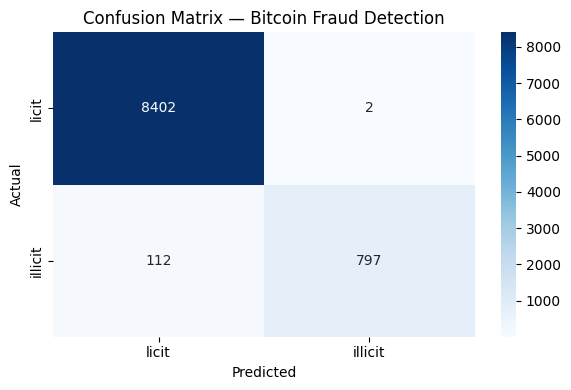

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['licit','illicit'],
            yticklabels=['licit','illicit'])
plt.title('Confusion Matrix — Bitcoin Fraud Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

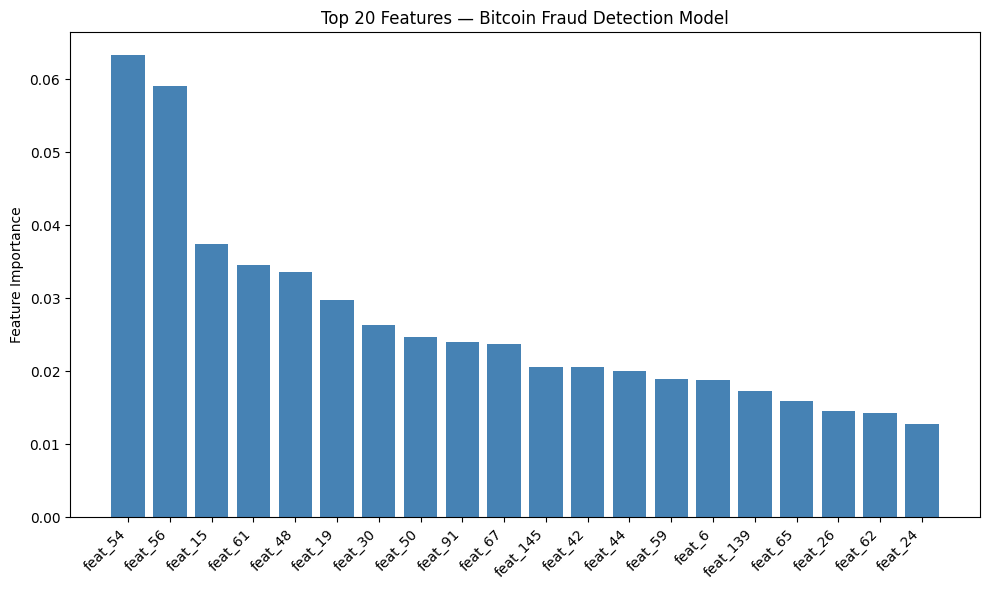

In [13]:
importances = rf.feature_importances_
feat_names = feature_cols_rf
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(10,6))
plt.bar(range(20), importances[indices], color='steelblue')
plt.xticks(range(20), [feat_names[i] for i in indices], rotation=45, ha='right')
plt.title('Top 20 Features — Bitcoin Fraud Detection Model')
plt.ylabel('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

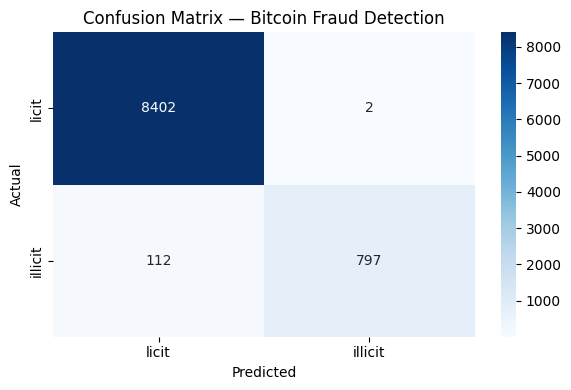

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['licit','illicit'],
            yticklabels=['licit','illicit'])
plt.title('Confusion Matrix — Bitcoin Fraud Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [15]:
results = df.iloc[X_test.shape[0]*-1:].copy()
results['predicted'] = y_pred
results['correct'] = (results['label'] == results['predicted']).astype(int)

export_cols = ['txId', 'label', 'predicted', 'correct', 'degree', 'anomaly_score']
results[export_cols].to_csv('predictions.csv', index=False)
print('Exported', len(results), 'predictions')
print(results['predicted'].value_counts())

Exported 9313 predictions
predicted
0    8514
1     799
Name: count, dtype: int64


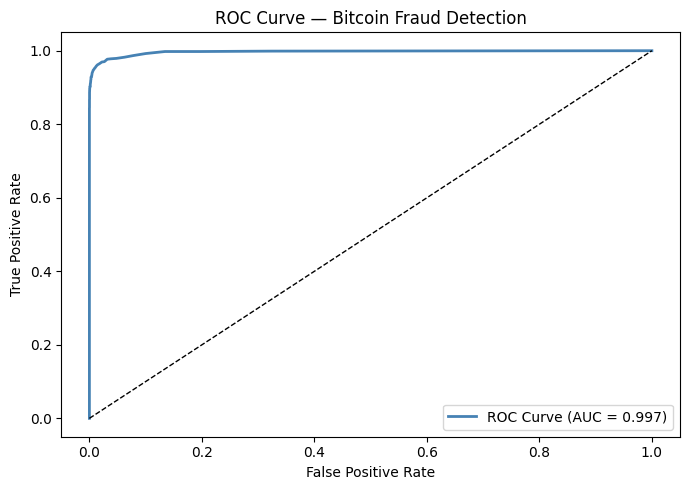

AUC Score: 0.9966


In [17]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Bitcoin Fraud Detection')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

print(f'AUC Score: {auc:.4f}')

In [19]:
import matplotlib
matplotlib.use('Agg')

fig1, ax1 = plt.subplots(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['licit','illicit'], yticklabels=['licit','illicit'], ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')
fig1.tight_layout()
fig1.savefig('/content/drive/MyDrive/Colab Notebooks/elliptic/confusion_matrix.png', dpi=150)

fig2, ax2 = plt.subplots(figsize=(7,5))
y_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
ax2.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
ax2.plot([0,1],[0,1],'k--')
ax2.set_title('ROC Curve')
fig2.savefig('/content/drive/MyDrive/Colab Notebooks/elliptic/roc_curve.png', dpi=150)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:20]
fig3, ax3 = plt.subplots(figsize=(10,6))
ax3.bar(range(20), importances[indices], color='steelblue')
ax3.set_xticks(range(20))
ax3.set_xticklabels([feature_cols_rf[i] for i in indices], rotation=45, ha='right')
ax3.set_title('Top 20 Features')
fig3.tight_layout()
fig3.savefig('/content/drive/MyDrive/Colab Notebooks/elliptic/feature_importance.png', dpi=150)

print('Done')

Done
